In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from geodesiq import Hamiltonian

In [3]:
def analytic(x: float, n_plus: float, z0: float, s: np.ndarray) -> np.ndarray:
    if n_plus == 0:
        return z0 * (1 - 2 * s)
    elif n_plus == 1:
        return x * np.sinh((1 - 2 * s) * np.arcsinh(z0 / x))
    elif n_plus == 2:
        return -x * np.tan((2 * s - 1) * np.arctan(z0 / x))
    elif n_plus == 3:
        return (1 - 2 * s) * x * z0 / np.sqrt(x ** 2 - 4 * (s - 1) * s * z0 ** 2)
    else:
        raise ValueError('No analytical solution available')

In [4]:
def H_fun(x, z):
    return np.array([[z, x], [x, -z]])

def H_partial(x, z):
    return np.array([[1, 0], [0, -1]])

alpha = 4
beta = 0
x = 1
z0 = -10

hamiltonian = Hamiltonian(H_fun)
hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=5, initial_state=0, alpha=alpha, beta=beta)
hamiltonian.solve_problem(pulse_accuracy=int(1e6))

[-10.          -9.98535156  -9.97070312 ...   4.97070312   4.98535156
   5.        ]


In [5]:
hamiltonian

------------------ Hamiltonian Control Summary ------------------
Hamiltonian: ✅ set
Partial Hamiltonian: ❌ not set
Hamiltonian parameters: x: 1
Control name → z
Pulse initial → -10
Pulse final → 5
Initial state index → 0
(Alpha, Beta) → (4, 0)
Eigenproblem solved → ✅ yes
Metric computed → ✅ yes
ODE solved → ✅ yes
---------------------------------------------------------------

In [8]:
hamiltonian._flags

Flags(
  eigenproblem_solved: stored=False,
  metric_computed: stored=False, parent='eigenproblem_solved'
  ode_solved: stored=False, parent='metric_computed'
)

In [16]:
hamiltonian.pulse_final = 2
hamiltonian.solve_problem(pulse_accuracy=int(1e6))

[-10.          -9.98828125  -9.9765625  ...   1.9765625    1.98828125
   2.        ]


The average errror is: 0.5828914329968835


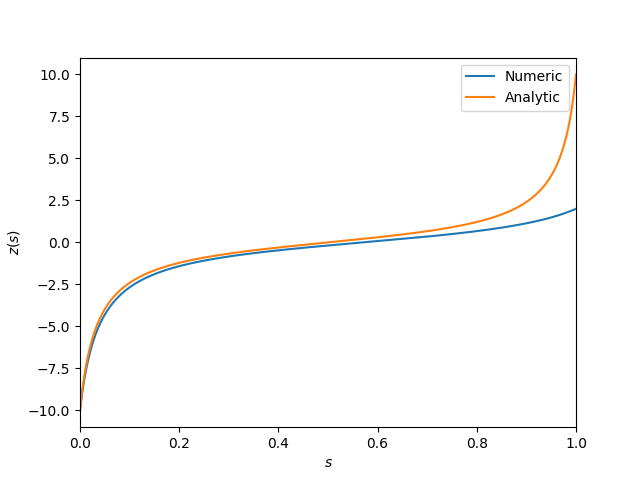

In [18]:
s, pulse = hamiltonian._s, hamiltonian.control_sol

fig, ax = plt.subplots()
ax.plot(s, pulse, label='Numeric')

try:
    pulse_an = analytic(x, (alpha + beta) / 2, z0, s)
    ax.plot(s, pulse_an, label='Analytic')

    error = np.sum(np.abs(pulse - pulse_an)) / len(s)
    print(f'The average errror is: {error}')
    
except:
    pass

ax.legend()
ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$z(s)$')
ax.set_xlim(0, 1);